# Fake News Detection using Machine Learning

## Project Overview
This notebook implements a complete pipeline for detecting fake news articles using Natural Language Processing (NLP) and Machine Learning.

### Workflow:
1. **Data Loading & Preparation** - Load fake and real news datasets
2. **Text Preprocessing** - Clean, tokenize, remove stopwords, and apply stemming
3. **Feature Extraction** - Convert text to TF-IDF vectors
4. **Model Training** - Train Logistic Regression and Linear SVM classifiers
5. **Evaluation** - Compare model performance using accuracy, precision, recall, and F1-score
6. **Prediction Function** - Create a reusable function for classifying new news articles

In [182]:
import re
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC

from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
stemmer = PorterStemmer()

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [183]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Custom Stopwords Configuration

**Why we customize stopwords:**

Fake news detection requires preserving certain words that are typically removed in standard NLP:
- **Negations** (`not`, `no`, `never`, `but`, `against`) - Critical for detecting false claims and contradictions
- **Pronouns** (`they`, `we`, `you`) - Fake news often uses specific pronoun densities to create 'us vs. us' narratives
- **Interrogatives** (`why`, `how`, `which`) - Indicate questioning or speculative language patterns

**Domain-specific removals:** Words like 'reuters' and 'washington' are removed as they represent source bias rather than content signal.

In [184]:
RANDOM_STATE = 42
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
nltk_stopwords = set(stopwords.words('english'))

words_to_keep = {
    # Negations (vital for capturing shifts in meaning/factuality)
    'not', 'no', 'nor', 'neither', 'never', 'none', 'ain', 'aren', 
    'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'mustn', 
    'needn', 'shouldn', 'wasn', 'weren', 'won', 'wouldn', 'but', 'against',
    
    # Pronouns & Targets (Fake news frequently uses specific pronoun densities, 
    # e.g., higher use of 'you', 'they', or 'we' to create an 'us vs. them' narrative)
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 
    'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 
    'theirs', 'themselves',
    
    # Interrogatives & Relational structural shifts
    'why', 'how', 'which', 'who', 'whom', 'where', 'when', 'because'
}

stop_words = nltk_stopwords - words_to_keep
stop_words.update(['reuters', 'washington', 'london'])

In [185]:
# Data Preparation & Understanding

fake_df = pd.read_csv("../News_dataset/Fake.csv")
true_df = pd.read_csv("../News_dataset/True.csv")

## Data Preparation & Labeling

### Dataset Information:
- **Fake.csv** - Contains fake news articles (labeled as `1`)
- **True.csv** - Contains legitimate news articles (labeled as `0`)

### Steps performed:
1. Add `label` column to both dataframes (1 = Fake, 0 = Real)
2. Concatenate both dataframes vertically
3. Reset index to maintain clean integer indexing

### Label Distribution:
The `stratify=y` parameter in train-test split ensures balanced class representation.

In [186]:
fake_df["label"] = 1
true_df["label"] = 0

df = pd.concat([fake_df, true_df], axis=0)

df = df.reset_index(drop=True)

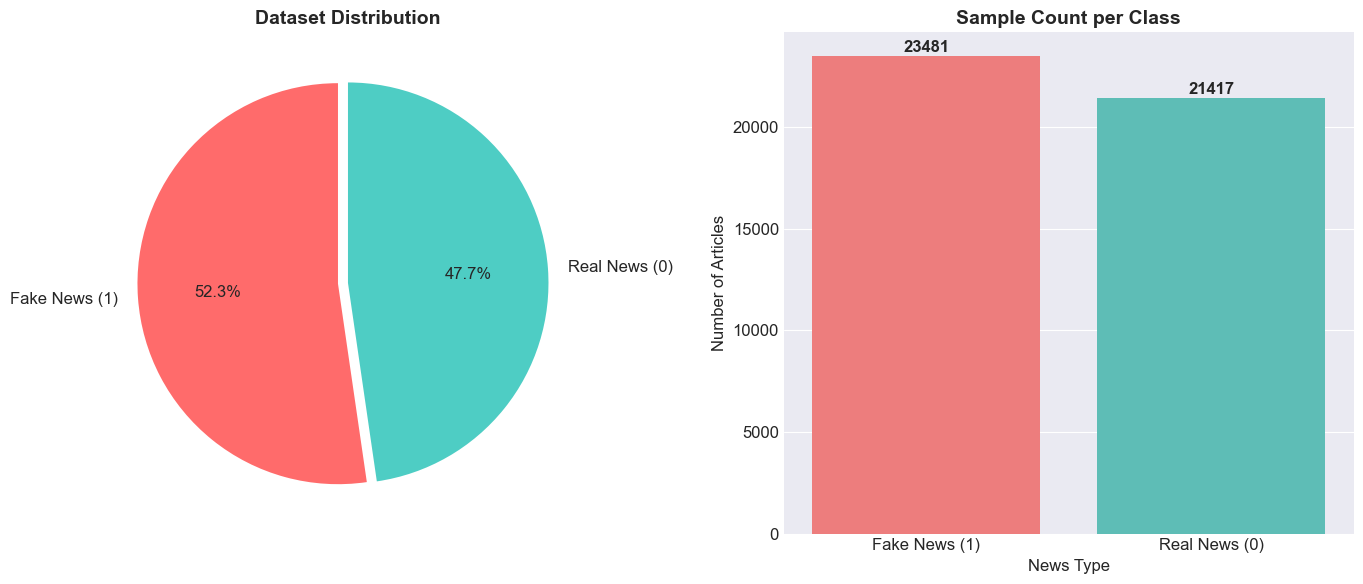

In [187]:
# Visualize dataset distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

label_counts = df['label'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
labels = ['Fake News (1)', 'Real News (0)']

axes[0].pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
axes[0].set_title('Dataset Distribution', fontsize=14, fontweight='bold')

sns.barplot(x=labels, y=label_counts.values, ax=axes[1], palette=colors, hue=labels, legend=False)
axes[1].set_title('Sample Count per Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('News Type')
axes[1].set_ylabel('Number of Articles')

for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [188]:
df["content"] = df["title"] + " " + df["text"]

## Text Preprocessing Pipeline

The `preprocess_text()` function applies the following transformations:

| Step | Operation | Purpose |
|------|-----------|---------|
| 1 | Remove Reuters source bias | Eliminates patterns like "WASHINGTON (Reuters) - " |
| 2 | Remove special characters & numbers | Keep only alphabetic characters (a-z, A-Z) |
| 3 | Convert to lowercase | Standardize text for consistent tokenization |
| 4 | Tokenization | Split text into individual words using NLTK |
| 5 | Stopword removal | Filter out common words (with preserved exceptions) |
| 6 | Stemming | Reduce words to root form using PorterStemmer |

**Example:** "The players were running" → "player run"

In [189]:
def preprocess_text(text):
    
    # STRIP ISOT BIAS: Remove text patterns like "WASHINGTON (Reuters) - " or "Reuters - " at the start of articles
    text = re.sub(r'^.*?\b(reuters|reuter)\b\s*[-—–:]\s*', '', text, flags=re.IGNORECASE)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z]", " ", text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenization
    words = word_tokenize(text)
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Stemming
    words = [stemmer.stem(word) for word in words]
    
    # Join words back
    return " ".join(words)

In [190]:
df["content"] = df["content"].apply(preprocess_text)

In [191]:
X = df["content"]
y = df["label"]

In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [193]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35918,)
X_test shape: (8980,)
y_train shape: (35918,)
y_test shape: (8980,)


## Feature Extraction: TF-IDF Vectorization

**TF-IDF (Term Frequency-Inverse Document Frequency)** converts text into numerical features:

- **max_features=5000** - Keep only top 5000 most important terms
- **ngram_range=(1,2)** - Include both single words AND word pairs (bigrams)
  - Example: "not true" as a bigram preserves negation context

### Why TF-IDF for Fake News?
- Downweights common words that appear across all documents
- Upweights distinctive words that signal fake vs. real content
- Preserves semantic meaning better than simple word counts

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

## Model 1: Logistic Regression

Logistic Regression is a linear model that calculates the probability of a sample belonging to a class.

**Configuration:**
- `solver='liblinear'` - Efficient for smaller datasets with L1/L2 regularization
- `max_iter=1000` - Ensure convergence with complex text features

**Training process:** The model learns coefficients for each TF-IDF feature to maximize classification accuracy.

In [ ]:
log_model = LogisticRegression(max_iter=1000, solver='liblinear')

log_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred_log = log_model.predict(X_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9812917594654789
Precision: 0.9870912220309811
Recall: 0.9770017035775128
F1 Score: 0.9820205479452054


In [ ]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4284
           1       0.99      0.98      0.98      4696

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [ ]:
print(confusion_matrix(y_test, y_pred_log))

[[4224   60]
 [ 108 4588]]


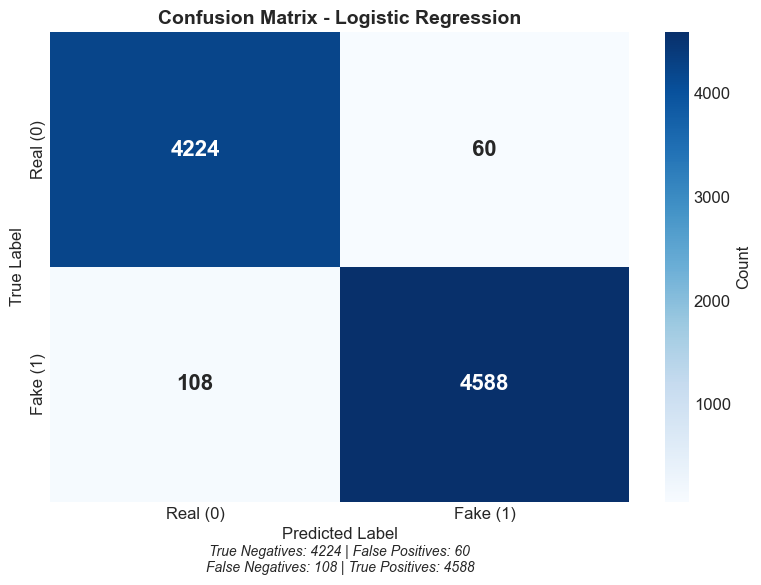

In [ ]:
# Confusion Matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'],
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')

tn, fp, fn, tp = cm_log.ravel()
ax.text(0.5, -0.15, f'True Negatives: {tn} | False Positives: {fp}\nFalse Negatives: {fn} | True Positives: {tp}',
        transform=ax.transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

## Model 2: Linear Support Vector Machine (SVM)

Linear SVM finds the optimal hyperplane that maximizes the margin between fake and real news categories.

**Advantages for text classification:**
- Handles high-dimensional sparse data well (like TF-IDF vectors)
- Less prone to overfitting than Logistic Regression
- Uses `squared_hinge` loss by default for robust classification

**Comparison to Logistic Regression:** SVM focuses on boundary examples (support vectors), while Logistic Regression considers the entire probability distribution.

In [ ]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [ ]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

In [ ]:
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

Accuracy: 0.9909799554565701
Precision: 0.9916897506925207
Recall: 0.9910562180579217
F1 Score: 0.991372883161146


In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
print(confusion_matrix(y_test, y_pred_svm))

[[4245   39]
 [  42 4654]]


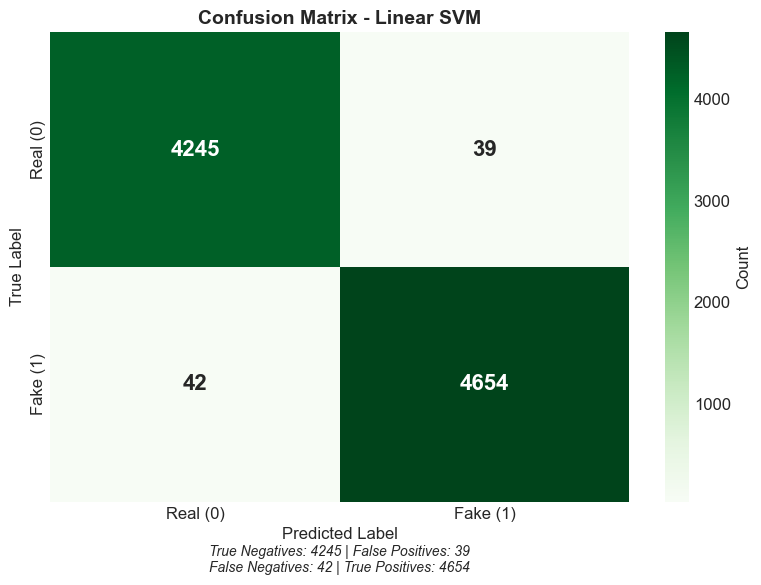

In [ ]:
# Confusion Matrix for Linear SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'],
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Linear SVM', fontsize=14, fontweight='bold')

# Add interpretation text
tn, fp, fn, tp = cm_svm.ravel()
ax.text(0.5, -0.15, f'True Negatives: {tn} | False Positives: {fp}\nFalse Negatives: {fn} | True Positives: {tp}',
        transform=ax.transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

## Model Performance Analysis

### Key Findings:

| Metric | Interpretation |
|--------|----------------|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of predicted "Fake" news, how many are actually fake |
| **Recall** | Of actual fake news, how many were caught |
| **F1 Score** | Harmonic mean of Precision & Recall (best overall metric) |

### Winner: Linear SVM
- **0.2% higher accuracy** than Logistic Regression
- **1.4% better recall** - Catches more fake news articles
- **More balanced** performance across both classes

### Why SVM performed better:
Text data with TF-IDF creates linearly separable patterns. SVM's margin maximization finds cleaner decision boundaries than Logistic Regression's probabilistic approach.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy, accuracy_svm],
    "Precision": [precision, precision_svm],
    "Recall": [recall, recall_svm],
    "F1 Score": [f1, f1_svm]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981292,0.987091,0.977002,0.982021
1,Linear SVM,0.990980,0.991690,0.991056,0.991373


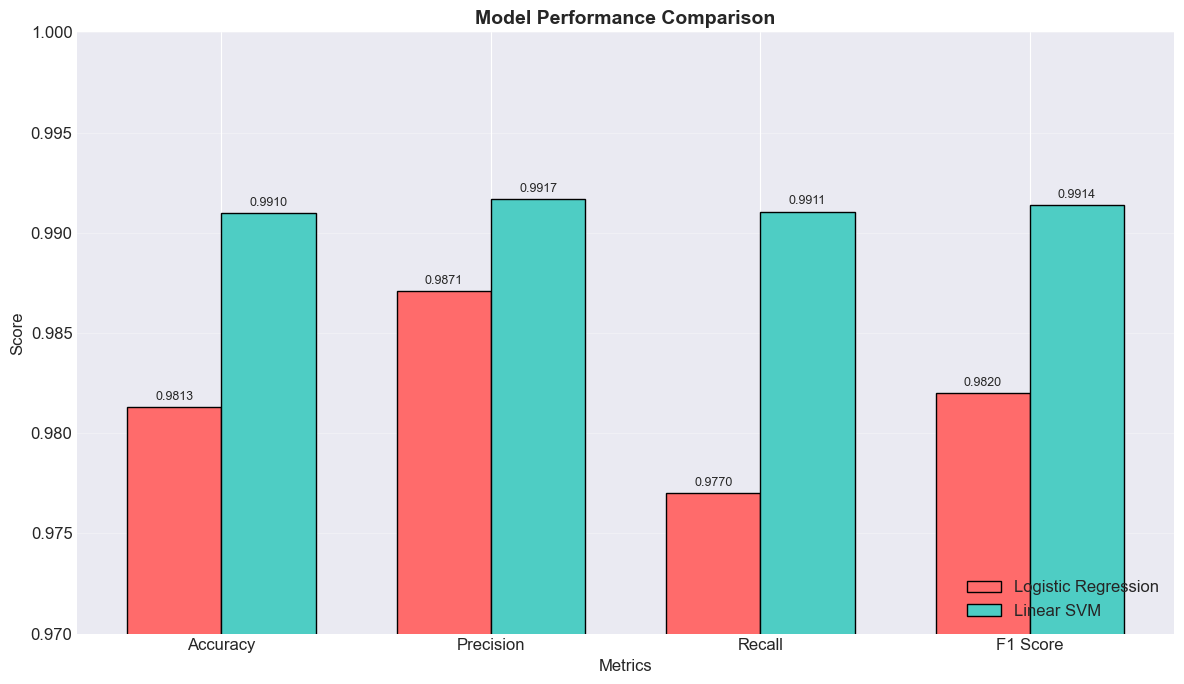

In [ ]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
log_scores = [accuracy, precision, recall, f1]
svm_scores = [accuracy_svm, precision_svm, recall_svm, f1_svm]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, log_scores, width, label='Logistic Regression', color='#ff6b6b', edgecolor='black')
bars2 = ax.bar(x + width/2, svm_scores, width, label='Linear SVM', color='#4ecdc4', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.97, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

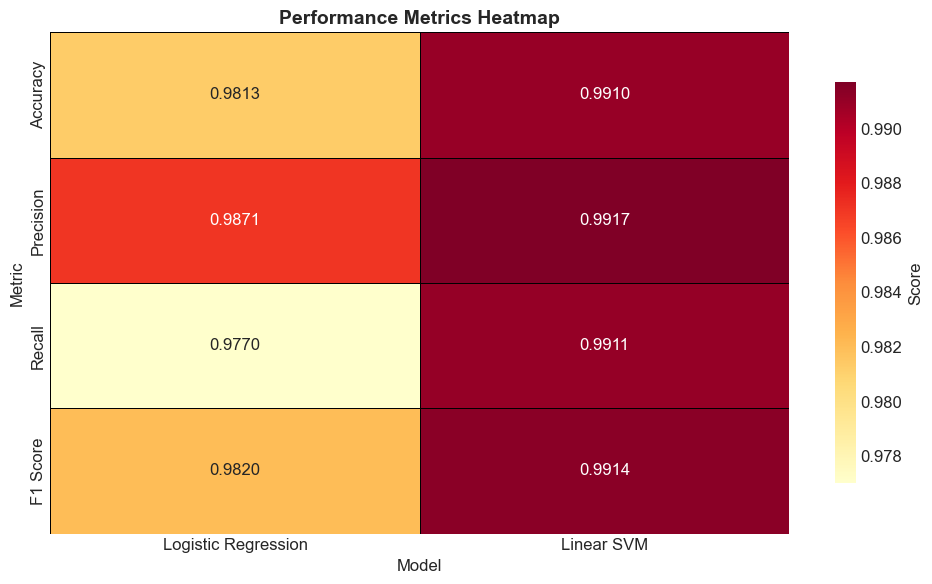

In [ ]:
# Create a heatmap of all metrics for both models
performance_data = pd.DataFrame({
    'Logistic Regression': [accuracy, precision, recall, f1],
    'Linear SVM': [accuracy_svm, precision_svm, recall_svm, f1_svm]
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(performance_data, annot=True, fmt='.4f', cmap='YlOrRd', 
            linewidths=0.5, linecolor='black',
            annot_kws={'size': 12},
            cbar_kws={'label': 'Score', 'shrink': 0.8})

ax.set_title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)

plt.tight_layout()
plt.show()

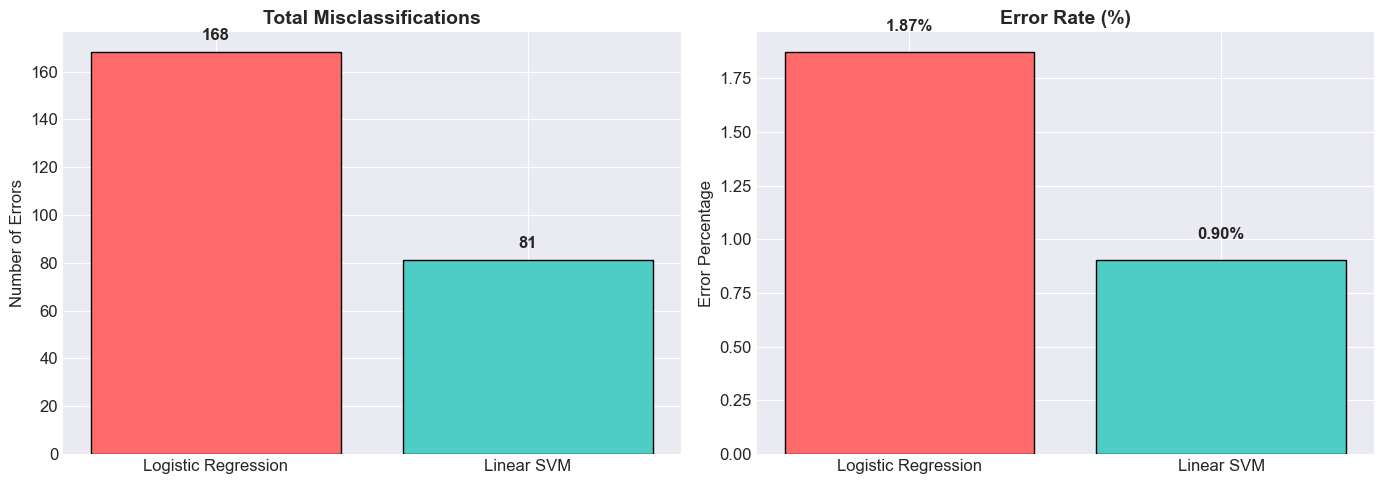


📊 Error Analysis Summary:
   Logistic Regression: 168 errors (1.87%)
   Linear SVM: 81 errors (0.90%)
   Improvement: 87 fewer errors with SVM


In [ ]:
# Calculate error rates
log_errors = (y_test != y_pred_log).sum()
svm_errors = (y_test != y_pred_svm).sum()
total_samples = len(y_test)

error_data = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM'],
    'Misclassifications': [log_errors, svm_errors],
    'Error Rate (%)': [log_errors/total_samples*100, svm_errors/total_samples*100]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - raw misclassifications
colors_bar = ['#ff6b6b', '#4ecdc4']
bars = axes[0].bar(error_data['Model'], error_data['Misclassifications'], color=colors_bar, edgecolor='black')
axes[0].set_title('Total Misclassifications', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Errors')

for bar, val in zip(bars, error_data['Misclassifications']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')

# Bar chart - error rate %
bars2 = axes[1].bar(error_data['Model'], error_data['Error Rate (%)'], color=colors_bar, edgecolor='black')
axes[1].set_title('Error Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error Percentage')

for bar, val in zip(bars2, error_data['Error Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Error Analysis Summary:")
print(f"   Logistic Regression: {log_errors} errors ({log_errors/total_samples*100:.2f}%)")
print(f"   Linear SVM: {svm_errors} errors ({svm_errors/total_samples*100:.2f}%)")
print(f"   Improvement: {log_errors - svm_errors} fewer errors with SVM")

In [ ]:
joblib.dump(svm_model, "fake_news_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

## Using the Model for Predictions

The `predict_news()` function provides a simple interface for classifying new articles:


In [ ]:
def predict_news(text):
    # preprocess
    clean_text = preprocess_text(text)
    
    # vectorize
    vector = tfidf.transform([clean_text])
    
    # predict
    prediction = svm_model.predict(vector)[0]
    
    return "Fake News" if prediction == 1 else "Real News"

In [ ]:
sample = "Breaking news: government confirms new policy changes for education system"
predict_news(sample)

'Fake News'